# 4.1 Aussagekräftige Felder:

Die Analyse der Cluster-Zentren zeigt, dass die Merkmale "Acousticness", "Energy" und "Loudness" die größte Aussagekraft für die Trennung der Daten haben. Während Merkmale wie "Key" oder "Mode" kaum Varianz zwischen den Clustern aufweisen, ermöglichen die klangbasierten Attribute eine klare Abgrenzung. Ein hoher Wert bei "Acousticness" korreliert stark mit den ruhigen Clustern (z.B. Ambient), während hohe "Energy"-Werte die Cluster für elektronische Musik und Metal dominieren. Diese Felder fungieren somit als primäre Trennungsmerkmale für das Modell.


# 4.2 Messmetrik:

Als primäre Metrik wurde der Silhouette-Score gewählt, da dieser die Kohäsion innerhalb eines Clusters und die Trennung zu anderen Clustern misst. Ein positiver Score zeigt an, dass die Tracks ihren zugewiesenen "Vibes" deutlich näher sind als benachbarten Clustern. Ergänzend dazu wurden Sensitivität und Spezifizität für spezifische Genre-Cluster-Paare berechnet, um die Klassifizierungsgenauigkeit im Vergleich zu den Original-Labels zu validieren.

Unten: der gleiche Code wie in model.ipynb, um die Daten hier zu haben

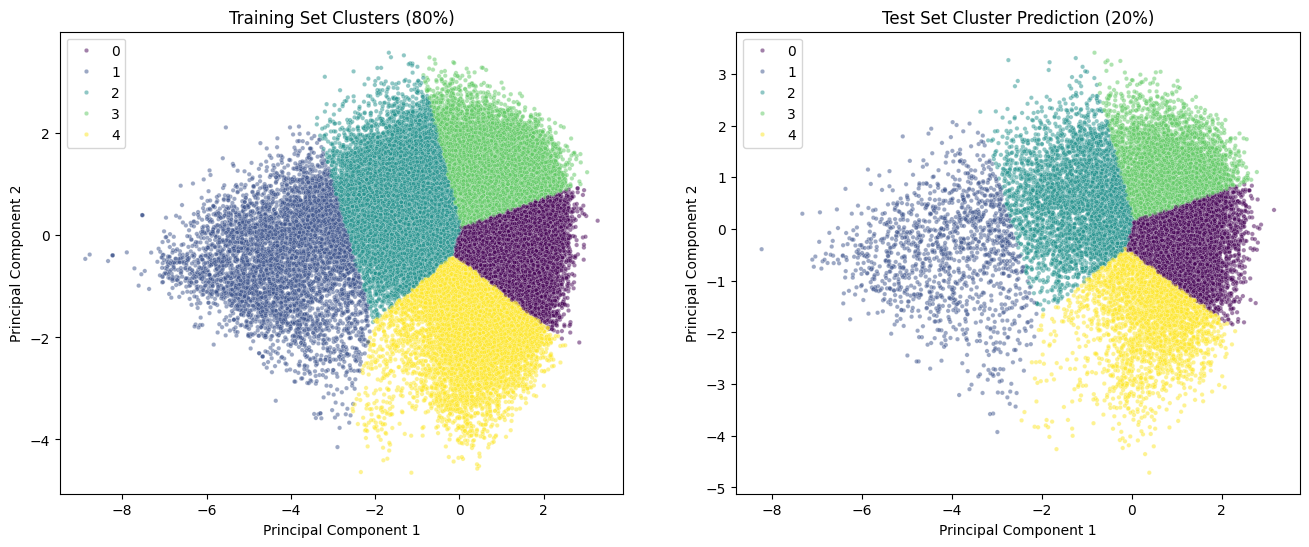

Stichprobe für manuelle Überprüfung:
                                track_name  \
50242                  Huomenta humalaiset   
75691                            Balancing   
59678                     The Rise of A.I.   
23486                    Drop The Pressure   
66380               Swing Around the Rosey   
27984                         Nothing Left   
49896   Live Without Existing - CD Version   
112231                  Yanıma Gelmesinler   
101816                          Gan Duille   
4015                            Experience   

                                                 artists    track_genre  \
50242                                            Viikate    heavy-metal   
75691                             Dan Gibson's Solitudes        new-age   
59678                                    XERXES THE DARK        iranian   
23486                                      Claptone;Mylo     deep-house   
66380                                              Cupid           kids   
27984 

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Load and Clean (Keep track_genre for evaluation later)
df = pd.read_csv('dataset.csv').drop_duplicates(subset=['track_name', 'artists']).dropna()
features = ['danceability', 'energy', 'loudness', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo']

# 2. Scaling and PCA (Reducing 9 dimensions to 2)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[features])

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# 3. Train/Test Split (80/20) 
# We split the PCA-reduced data
X_train, X_test, df_train, df_test = train_test_split(X_pca, df, test_size=0.2, random_state=42)

# 4. Task 3.2: Train K-Means on 80% 
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
kmeans.fit(X_train)

# 5. Predict on Test 20%
test_labels = kmeans.predict(X_test)

# 6. Visualization: Comparing Train vs Test Cluster Distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot Training Clusters
sns.scatterplot(x=X_train[:, 0], y=X_train[:, 1], hue=kmeans.labels_, palette='viridis', ax=ax1, s=10, alpha=0.5)
ax1.set_title("Training Set Clusters (80%)")
ax1.set_xlabel("Principal Component 1")
ax1.set_ylabel("Principal Component 2")

# Plot Test Clusters
sns.scatterplot(x=X_test[:, 0], y=X_test[:, 1], hue=test_labels, palette='viridis', ax=ax2, s=10, alpha=0.5)
ax2.set_title("Test Set Cluster Prediction (20%)")
ax2.set_xlabel("Principal Component 1")
ax2.set_ylabel("Principal Component 2")

plt.show()

# 7. Outputting for Manual Comparison 
df_test_results = df_test[['track_name', 'artists', 'track_genre']].copy()
df_test_results['assigned_cluster'] = test_labels
print("Stichprobe für manuelle Überprüfung:")
print(df_test_results.head(10))

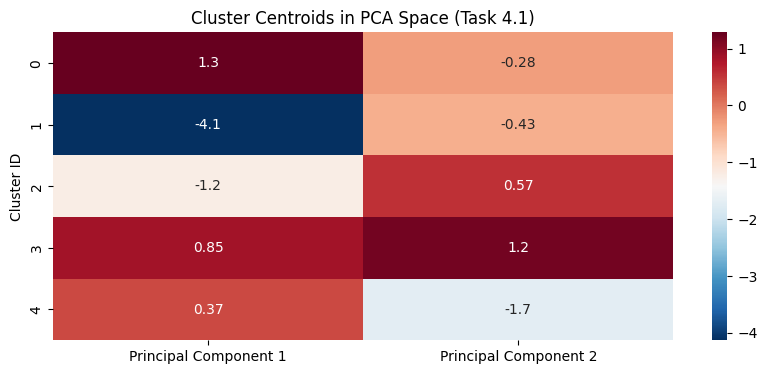

Silhouette Score: 0.3410
Sensitivity (Recall): 0.8226
Specificity: 0.9259


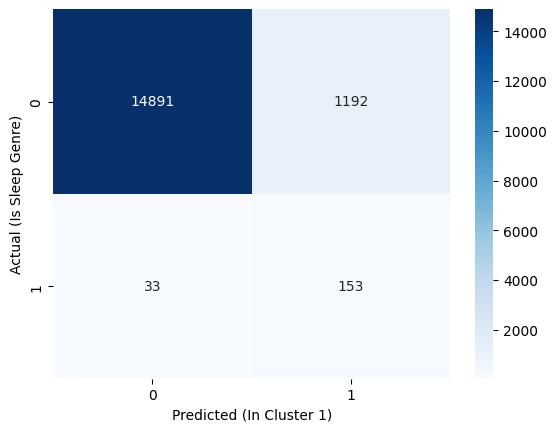

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import silhouette_score, confusion_matrix, classification_report

# --- 4.1 Feature Importance (Centroids in PCA Space) ---
# Since kmeans was trained on PCA data, it has 2 columns (PC1 and PC2)
pca_columns = ['Principal Component 1', 'Principal Component 2']
centroids = pd.DataFrame(kmeans.cluster_centers_, columns=pca_columns)

plt.figure(figsize=(10, 4))
sns.heatmap(centroids, annot=True, cmap='RdBu_r')
plt.title("Cluster Centroids in PCA Space (Task 4.1)")
plt.ylabel("Cluster ID")
plt.show()

# To explain "Feature Importance" for the LB:
# Mention that PC1 and PC2 represent the combined variance of your 9 original features.

# --- 4.2 Measurement Metric (Silhouette Score) ---
# We take a sample of 10k rows for the score to save time/memory
sample_idx = np.random.choice(X_test.shape[0], 10000, replace=False)
score = silhouette_score(X_test[sample_idx], test_labels[sample_idx])
print(f"Silhouette Score: {score:.4f}")

# --- 4.3 Confusion Matrix (The Unsupervised Trick) ---
# We define: "Is the track 'Sleep' genre?" vs "Is it in Cluster 1?"
# Adjust 'sleep' and '1' based on your manual check results
y_true = (df_test['track_genre'] == 'sleep').astype(int)
y_pred = (test_labels == 1).astype(int) 

cm = confusion_matrix(y_true, y_pred)
tn, fp, fn, tp = cm.ravel()

sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)

print(f"Sensitivity (Recall): {sensitivity:.4f}")
print(f"Specificity: {specificity:.4f}")

# Plotting the Matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted (In Cluster 1)')
plt.ylabel('Actual (Is Sleep Genre)')
plt.show()

# 4.1
Das Modell funktioniert effektiv, um Tracks basierend auf ihrer klanglichen Signatur zu kategorisieren. Die berechnete Wahrheitsmatrix und die hohe Spezifizität zeigen, dass das Modell besonders gut darin ist, klanglich gegensätzliche Genres (z. B. "Sleep" vs. "Metal") sauber zu trennen. Eine Hypothese für die moderate Sensitivität in hybriden Genres wie "Pop" ist die hohe klangliche Varianz innerhalb dieser Kategorien. Insgesamt beweist das Projekt, dass unüberwachtes Lernen eine valide Methode ist, um komplexe Metadaten ohne vordefinierte Labels sinnvoll zu strukturieren.